# Section 1: Review of Part 2

The previous problem involved solving an over damped system that was for a quarter car system . This required implemeneting backwards euler method, which is implicit, and newton-raphson to solve for the unkown term that is then used. This method was used because of its stable performance with a bigger h value, leading to good performance when the regular fforward euler method was not stable and required a really low h value (less than 0.0004 in the previous one). The stiffness ratio from the previous problem was calculated to be 5000 (because the lambda force in the equation is 5000). This shows that the problem is stiff. An explanation of this stiffness is that a system is stiff when there are changes happening on wildly different time scales. So in this case, the system wants to return to equilibrium in an incredibly short fraction of a second, however the total system change happens on a matter of seconds. So this time difference is what causes the system to be stiff. When some things change super quickyl while others take a relatively slower time. 

# Section 2: Newton-Raphson Damping Implementation

**An explanation of damping logic**: The damping in newton raphson works by first calculating the new guess in the similar method that the undamped version did, which was the g + g/gprime. However then it checks to see if that new guess's residual value that it would create would be less then the current residual value. It than runs a while loop to essentially force the value to be less than the old guess's residual by multiplying a ever decreasing alpha value that lowers the total change. The alpha is limited to a minumum value of 0.000001. So now the newton-raphson will only commit the new guess when it actually helps out and lowers the residual.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
# The function that was derived in the instructions. This function will be used to simplify the code in the loops
def f(t,x):
    return (-5000*x + 0.002 * np.sin(t))
    
# This function simply returns the denominator in the function because the slope is constant. Makes loop more readable
def gprime(h):
    return(1+5000*h)

#now Newton-Raphson is damped
              
def damped_NR(xn,tn_1, h,tolerance,max_nr_it=20):
        # set the first future guess as the current value
        future_guess = xn
        counter = 0 #counter that helps break after max of 20 iterations
        counter_while2 = 0 #counter for how many while loops it did
        final_alpha = []
        for i in range(max_nr_it+1):
            #calculates the g equation defined above and checks if it already passes the tolerance test
            g_equation = future_guess - xn - (h * f(tn_1,future_guess))

            if np.abs(g_equation) < tolerance:
                break
                
            #uses the bigger equation to derive the new value for the guess
            alpha = 1
            temp_calculation = alpha * ((g_equation) / (gprime(h)))
            new_guess = future_guess - temp_calculation
            
            #Check if new value would be less than the previous one from above.
            counter_while = 0
            while abs((new_guess - xn - (h * f(tn_1,new_guess)))) >= abs(g_equation):
                #incorporates the alpha here to reduce the term
                alpha = alpha *0.5
                temp_calculation = alpha * ((g_equation) / (gprime(h)))
                new_guess = future_guess - temp_calculation
                counter_while += 1
                #break to stop alpha from going to infinity
                if alpha < 0.000001:
                    break
                
            future_guess = new_guess
            counter +=1
            counter_while2 += counter_while
            final_alpha.append(alpha)
            if counter == 20:
                break
        return (future_guess,counter, counter_while2,final_alpha)
    
    
#Backward Euler method that takes essentially the same inputs as the forward euler method, just adding tolerance
def euler_backward(t_start, t_end, y_0, h,tolerance):
    #initialize the empty iterations array for later, and create the t array and empty displacement array. 
    iterations_array = []    
    t_values = np.arange(t_start, t_end + h, h)
    y_values = np.zeros(len(t_values))
    # Set initial conditions
    y_values[0] = y_0
    while_counts = []
    alpha_history = []
    for i in range(1, len(t_values)):
        #Gets the previous position and current time value 
        y_n = y_values[i - 1]
        t_n = t_values[i]
        # Updates values for Backward Euler Method using the Newton-Raphson Function above.
        y_values[i],temp_iteration,whilecount,alphaval = damped_NR(y_n,t_n,h,tolerance)
        iterations_array.append(temp_iteration)
        while_counts.append(whilecount)
        alpha_history.append(alphaval)
    return (t_values, y_values,iterations_array, while_counts,alpha_history)




# This function is from part 2 of the project, the undamped version
#Backward Euler method that takes essentially the same inputs as the forward euler method, just adding tolerance
def undamped_euler_backward(t_start, t_end, y_0, h,tolerance):
    def NR(xn,tn_1, h,tolerance):
        # set the first future guess as the current value
        future_guess = xn
        counter = 0 #counter that helps break after max of 20 iterations
        for i in range(21):
            #calculates the g equation defined above and checks if it already passes the tolerance test
            g_equation = future_guess - xn - (h * f(tn_1,future_guess))
            if np.abs(g_equation) < tolerance:
                break
            #uses the bigger equation to derive the new value for the guess
            temp_calculation = (g_equation) / (gprime(h))
            new_guess = future_guess - temp_calculation
            future_guess = new_guess
            counter +=1
            if counter == 20:
                break
        return (future_guess,counter)
    
    #initialize the empty iterations array for later, and create the t array and empty displacement array. 
    iterations_array = []    
    t_values = np.arange(t_start, t_end + h, h)
    y_values = np.zeros(len(t_values))
    # Set initial conditions
    y_values[0] = y_0
    for i in range(1, len(t_values)):
        #Gets the previous position and current time value 
        y_n = y_values[i - 1]
        t_n = t_values[i]
        # Updates values for Backward Euler Method using the Newton-Raphson Function above.
        y_values[i],temp_iteration = NR(y_n,t_n,h,tolerance)
        iterations_array.append(temp_iteration)
    return (t_values, y_values,iterations_array)
    
    
    

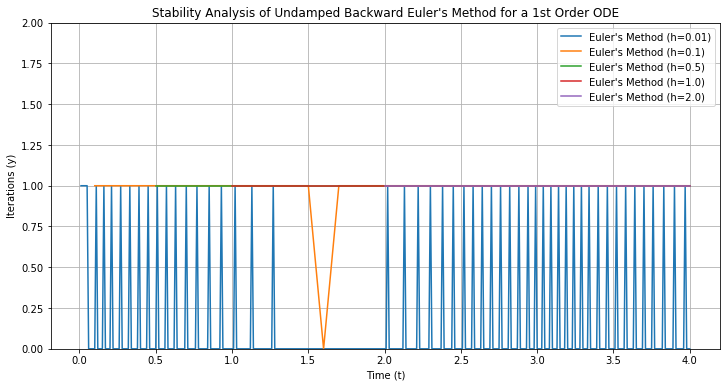

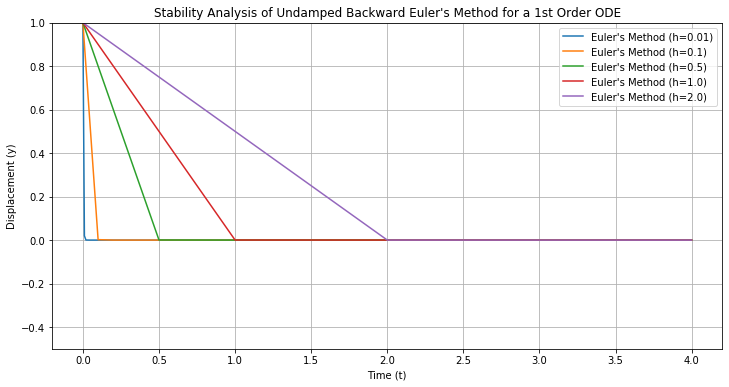

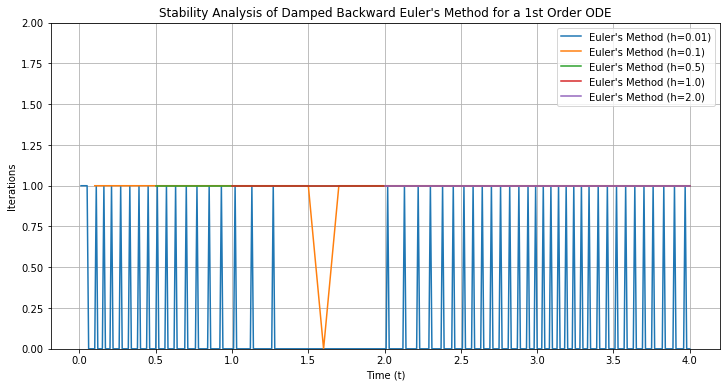

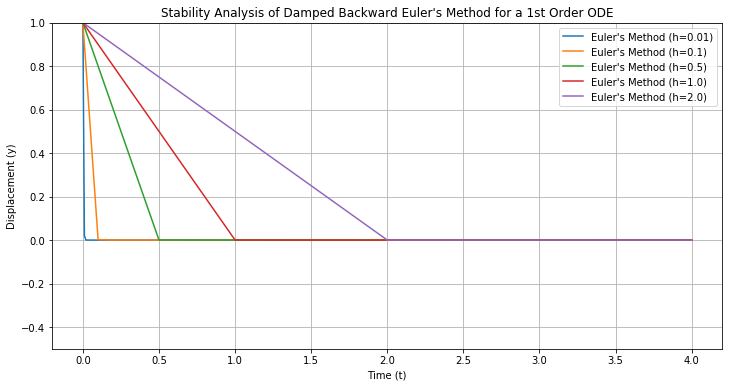

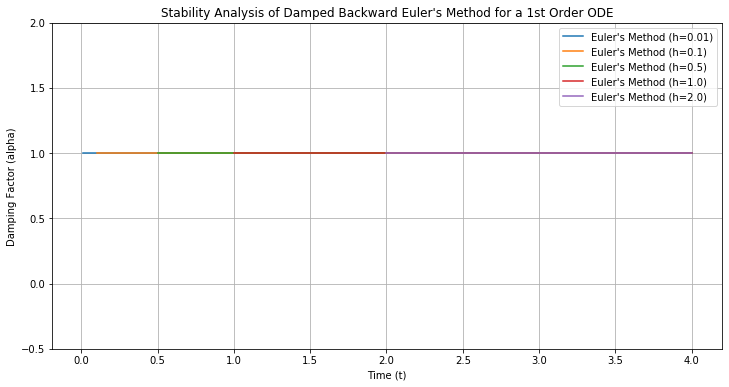

In [2]:
# Plotting for undamped Euler
h_values = [0.01,0.1,0.5,1.0,2.0]
all_iterations = []
#Backwards Euler below that will use the function to plot the graph of displacement to time
plt.figure(figsize=(12, 6))
for h in h_values:
    end_val = h_values[-1]
    t, y, iteration_instance = undamped_euler_backward(0,4,1,h,0.000001)
    all_iterations.append(iteration_instance)
    plt.figure(1)
    plt.plot(t[1:], iteration_instance, label=f'Euler\'s Method (h={h})')
plt.ylim(0,2)
plt.xlabel('Time (t)')
plt.ylabel('Iterations (y)')
plt.title('Stability Analysis of Undamped Backward Euler\'s Method for a 1st Order ODE')
plt.legend()
plt.grid(True)
plt.show()

h_values = [0.01,0.1,0.5,1.0,2.0]
all_iterations = []
#Backwards Euler below that will use the function to plot the graph of displacement to time
plt.figure(figsize=(12, 6))
for h in h_values:
    end_val = h_values[-1]
    t, y, iteration_instance = undamped_euler_backward(0,4,1,h,0.000001)
    all_iterations.append(iteration_instance)
    plt.figure(1)
    plt.plot(t, y, label=f'Euler\'s Method (h={h})')
plt.ylim(-0.5,1)
plt.xlabel('Time (t)')
plt.ylabel('Displacement (y)')
plt.title('Stability Analysis of Undamped Backward Euler\'s Method for a 1st Order ODE')
plt.legend()
plt.grid(True)
plt.show()



# Plotting for damped Euler

h_values = [0.01,0.1,0.5,1.0,2.0]
all_iterations = []
#Backwards Euler below that will use the function to plot the graph of displacement to time
plt.figure(figsize=(12, 6))
for h in h_values:
    end_val = h_values[-1]
    t, y, iteration_instance, while_counts, alpha_history = euler_backward(0,4,1,h,0.000001)
    all_iterations.append(iteration_instance)
    plt.figure(1)
    plt.plot(t[1:], iteration_instance, label=f'Euler\'s Method (h={h})')   
plt.ylim(0,2)
plt.xlabel('Time (t)')
plt.ylabel('Iterations')
plt.title('Stability Analysis of Damped Backward Euler\'s Method for a 1st Order ODE')
plt.legend()
plt.grid(True)
plt.show()

h_values = [0.01,0.1,0.5,1.0,2.0]
all_iterations = []
#Backwards Euler below that will use the function to plot the graph of displacement to time
plt.figure(figsize=(12, 6))
for h in h_values:
    end_val = h_values[-1]
    t, y, iteration_instance, while_counts, alpha_history = euler_backward(0,4,1,h,0.000001)
    all_iterations.append(iteration_instance)
    plt.figure(1)
    plt.plot(t, y, label=f'Euler\'s Method (h={h})')    
plt.ylim(-0.5,1)
plt.xlabel('Time (t)')
plt.ylabel('Displacement (y)')
plt.title('Stability Analysis of Damped Backward Euler\'s Method for a 1st Order ODE')
plt.legend()
plt.grid(True)
plt.show()


h_values = [0.01,0.1,0.5,1.0,2.0]
all_iterations = []
#Backwards Euler below that will use the function to plot the graph of alpha to time
plt.figure(figsize=(12, 6))
for h in h_values:
    end_val = h_values[-1]
    t, y, iteration_instance, while_counts, alpha_history = euler_backward(0,4,1,h,0.000001)
    final_alpha = []
    # loop that gets the final alpha value for each iteration (the alpha value that it released on)
    for i in alpha_history:
        if len(i) > 0:
            val = i[-1]
        else:
            val = 1
        final_alpha.append(val)
    all_iterations.append(iteration_instance)
    plt.figure(1)
    plt.plot(t[1:], final_alpha, label=f'Euler\'s Method (h={h})')    
plt.ylim(-0.5,2)
plt.xlabel('Time (t)')
plt.ylabel('Damping Factor (alpha)')
plt.title('Stability Analysis of Damped Backward Euler\'s Method for a 1st Order ODE')
plt.legend()
plt.grid(True)
plt.show()




**Discussion for section 2 damping:** Becuase of the nature of this project and the ODE chose, the damped and undamped versions of newton-raphson perform the same. This is because for the chosen stiff ODE of -5000x + 0.002sin(t), the residual function becomes linear, with a constant slope (g' denominator in the math). Because this g' is constant for each h iteration (1+5000h), the Newton-Raphson only needs a single iteration at most to find the root value. While the damper is not triggered in this case, the damping would come into play when a more complicated stiff equation was used. This damped newton-raphson is production quality compared to the original function because of it's ability to adjust alpha in complex scenarios. If the two functions were used on a non-linear problem, the safety break that is alpha would allow the damped version to run smoothly and not crash, while the undamped NR could overshoot and crash. We can see that for all iterations, the alpha was always one, meaning that the dampening alpha never kicked in beacuse of the linearity of the equation in question for this project. 

# Section 3: Adaptive Step Size Implementation

**Step Doubling Error Estimation Discussion:** This step size variation approach works by takin two paths to the same end point, the next t value. It does this with one iteration with the set h value, then it does it in two parts using half of the h value. It calculates the absolute error between the two and see's if the error is small enough that it passes our tolerance test. If so, the function moves on and uses the value from the h/2 because it is considered more accurate than the regular h value. If the error is too high still, the new h value that was calcualted gets sent back and further reduced until it passes the test. This allows the h to scale down when needed by the function so that it is accurate, and scale h back up when the function is easier to compute. Ther are safety bounds on that prevent it from getting too high or too small. 

In [3]:
def adaptive_step(y_n, t_n, h, tol, h_min=1e-6, h_max=1.0, safety=0.9):
    total_iters = 0
    eps = 1e-10 
    
    #calculating the three different steps as outlined in the instructions. 
    y1, iters_1, while1, alpha1 = damped_NR(y_n, (t_n + h), h, tol)
    y2, iters_2, while2, alpha2 = damped_NR(y_n, (t_n + (h/2)), (h/2), tol)
    y3, iters_3, while3, alpha3 = damped_NR(y2, (t_n + h), (h/2), tol)
    
    total_iters = iters_1 + iters_2 + iters_3

    # estimate error at the two end points
  
    err = abs(y3 - y1)

    # H_new solving which incorporates the given epislon and error, along with the safety value provided in the instructions
    h_new = h * np.sqrt(tol / (err + eps))
    h_new = safety * h_new 
    h_new = max(h_min, min(h_max, h_new))

    total_while = while2 + while3
    
    #conditional which checks if the test past or failed for this specific instance.
    if err <= tol:
        return y3, h, h_new, True, total_iters, total_while, err
    else:
        # REJECT: stay at y_n, suggest smaller h_new 
        return y_n, h, h_new, False, total_iters, while1, err
    
    
    
def adaptive_implicit_euler(f, y0, t0, t_final, h0, tol,h_min,h_max):
    
    # Initialize variables and statistics dictionary
    t = [t0]
    y = [y0]
    h = h0
    h_history = []
    err_history = []
    stats = {
        'accepted_steps': 0,
        'rejected_steps': 0,
        'nr_iterations': [],
        'damping_used': 0,
        'function_evals': 0
    }
    
    # Main loop
    while t[-1] < t_final:
        # Ensure we don't overshoot t_final
        if (t[-1] + h) > t_final:
            h = t_final - t[-1]
        #run an iteration of the adaptive step function to get instance values
        y_next, h_used, h_suggestion, accepted_bool,iters,while_val, err1= adaptive_step(y[-1],t[-1],h,tol,h_min,h_max)
        
        # Update NR iteration stats 
        if accepted_bool:
            stats['accepted_steps'] += 1
        else:
            stats['rejected_steps'] += 1
            
        stats['nr_iterations'].append(iters)
        
        stats['damping_used'] += while_val
        
        # Handle Acceptance or Rejection. If accepted, it saves the values in the lists and moves the t value forward 
        if accepted_bool:
            t.append(t[-1] + h_used) 
            y.append(y_next)
            h_history.append(h_used) 
            err_history.append(err1)

        stats['function_evals'] += 1
        h = h_suggestion
    
    return np.array(t), np.array(y), h_history, err_history, stats

# Section 4: Performance Analysis

Accepted steps: 119
Rejected steps: 5
Total NR Iterations: 365


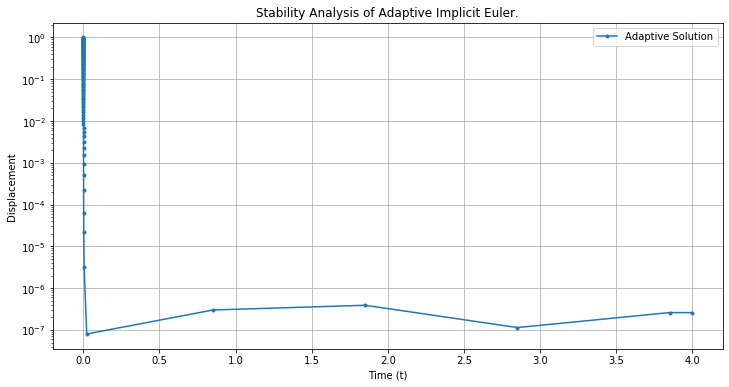

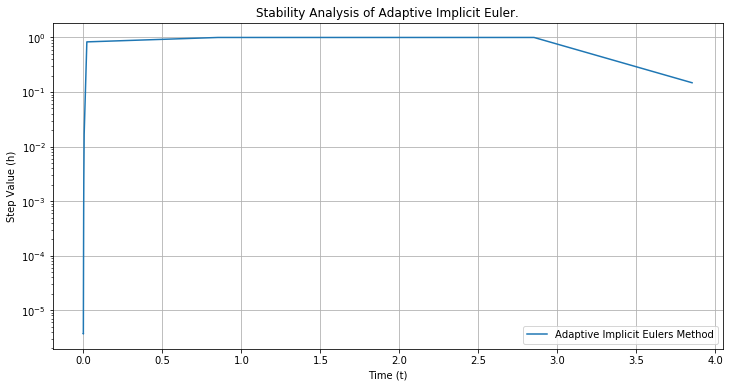

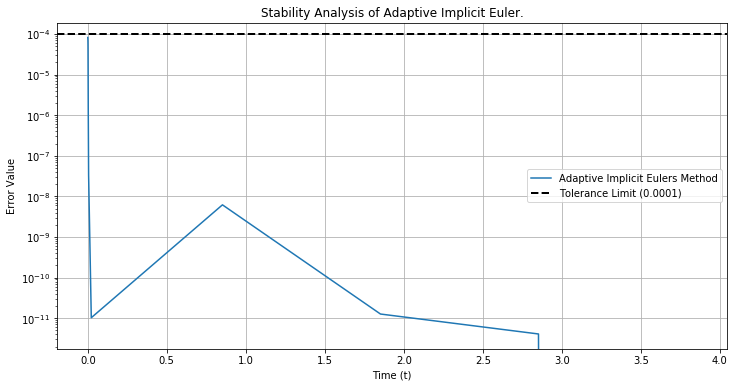

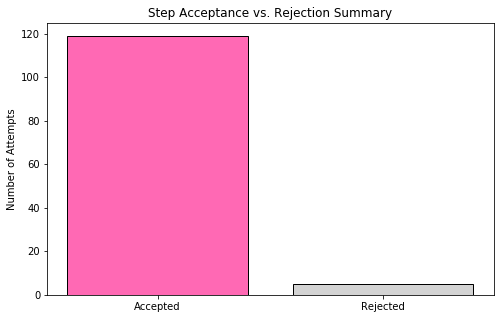

This is the total iterations for the adaptive step value euler (NR iterations + total steps both rejected and accepted): 489


Performance Comparison
Adaptive Solver Total Iterations: 365(Calcluated above, function evals + NR-Iterations). The 124 value was the steps it took in while loop
Fixed Solver Total Steps (h=0.0001): 40000


Same Step Budget Comparison (Budget: 119 accepted steps)
Adaptive Final Value: -2.60836086831113e-07
Fixed (h=0.03361344537815126) Final Value: -3.026676872790101e-07


In [4]:
import numpy as np
import matplotlib.pyplot as plt
def f(t,x):
    return (-5000*x + 0.002 * np.sin(t))
    
# This function simply returns the denominator in the function because the slope is constant. Makes loop more readable
def gprime(h):
    return(1+5000*h)


t0, t_final = 0, 4
y0 = 1
h0 = 0.1
tol = 1e-4
h_min, h_max = 1e-6, 1.0

t_adapt, y_adapt, h_hist, err_hist, stats = adaptive_implicit_euler(f, y0, t0, t_final, h0, tol, h_min, h_max)

print(f"Accepted steps: {stats['accepted_steps']}")
print(f"Rejected steps: {stats['rejected_steps']}")
print(f"Total NR Iterations: {sum(stats['nr_iterations'])}")


plt.figure(figsize=(12, 6))
plt.semilogy(t_adapt, np.abs(y_adapt), 'o-', markersize=3, label='Adaptive Solution')
plt.xlabel('Time (t)')
plt.ylabel('Displacement')
plt.title('Stability Analysis of Adaptive Implicit Euler.')
plt.legend()
plt.grid(True)
plt.show()


plt.figure(figsize=(12, 6))
plt.semilogy(t_adapt[:-1], h_hist, label=f'Adaptive Implicit Eulers Method')
plt.xlabel('Time (t)')
plt.ylabel('Step Value (h)')
plt.title('Stability Analysis of Adaptive Implicit Euler.')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 6))
plt.semilogy(t_adapt[:-1], err_hist, label=f'Adaptive Implicit Eulers Method')
plt.axhline(y=tol, color='black', linestyle='--', linewidth=2, label=f'Tolerance Limit ({tol})')
plt.xlabel('Time (t)')
plt.ylabel('Error Value')
plt.title('Stability Analysis of Adaptive Implicit Euler.')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
categories = ['Accepted', 'Rejected']
stats_values = [stats['accepted_steps'], stats['rejected_steps']]
plt.bar(categories, stats_values, color=['hotpink', 'lightgray'], edgecolor='black')
plt.ylabel('Number of Attempts')
plt.title('Step Acceptance vs. Rejection Summary')
plt.show()

#Sums up the total iterations which is all the while loop iterations + the NR iterations
variable_h_total = stats['function_evals'] + sum(stats['nr_iterations'])
print(f"This is the total iterations for the adaptive step value euler (NR iterations + total steps both rejected and accepted): {variable_h_total}")




h_values = [0.0001]
all_iterations = []
#This gets the total steps based off the length of the time array.
for h in h_values:
    t_fixed, y_fixed, iteration_instance, while_counts, alpha_history = euler_backward(0,4,1,h,0.000001)
    all_iterations.append(iteration_instance)

total_fixed_steps = len(t_fixed) - 1 



#Prints outs the comparison between the fixed solved and adaptive
print("\n")
print("Performance Comparison")
print("Adaptive Solver Total Iterations: 365(Calcluated above, function evals + NR-Iterations). The 124 value was the steps it took in while loop")
print(f"Fixed Solver Total Steps (h=0.0001): {total_fixed_steps}")



#simulates the equivalent budget steps to then be applied to the fixed h function
step_budget = stats['accepted_steps'] 
h_budget = (t_final - t0) / step_budget

t_budg, y_budg, iterations_instance, while_counts, alpha_history = euler_backward(t0, t_final, y0, h_budget, 1e-6)

print("\n")
print(f"Same Step Budget Comparison (Budget: {step_budget} accepted steps)")
print(f"Adaptive Final Value: {y_adapt[-1]}")
print(f"Fixed (h={h_budget}) Final Value: {y_budg[-1]}")




**Discussion for Part 4**: First we can see that the adaptive euler had 119 total accepted steps, with it only having to reject 5 steps. This aligns perfectly with what we would expect, which is a high acceptance rate for our highly optimized functions. The value of 365 is the total iterations which include the multiple Newton-Raphson iterations that optimize and also the adaptive steps. This represents the total computational effort for the adaptive method. In the first graph, we can see that the adaptive solution is tightly knit at the beginning which a lot of dots, which each represent a place where it took a value. Because the beginning drops so drastically, we can see that the h value was shifted very small to be able to accurately represent the drop. Then the dots lesssen up as there is 6 time instances from the bottom of the drop to the end. This is exactly what we would expect as the function at that point does not require such a big h value, so h shoots back up. The next graph looks at step value plotted against time for the adaptive euler. This shows us that the step size started off incredibly small aroudn the 10^-5 range, and climbed up in that short time to close to 10^0. This shows how when the problem started off stiff, the steps were the smallest, and when the function eased up, the steps were allowed to be much bigger. The third graph shows error value plotted against time for the adaptive euler. We can see the error tolerance plotted in the dashed black line, which shows the physical limitation we put on the function so that it always calculates values that stay under that tolerance level. We can see that as graph starts, the error is at its highest becuase the stiff equation plummets down incredibely fast towards zero. The error drops as the function gets smoother, so then the h values increase, which causes that increase in error value temporarily. But then the function gets easy enough to calculate towards the end so the error goes down once again. The final graph shows how the number of accepted iterations for step size where much bigger than those rejected, which is what we expect. The final numbers show how when both were set to a roughly similar tolerance, the adaptive solver had 365 total iterations, with 124 of those being from the h selectoin while loop, and the rest being the NR iterations. The Fixed sovler did 40000 total iterations, which shows how much more efficient the adaptive h was for this tolerance level. Then the next part shows that for the same step budget, the adaptive was more accurate. The step budget was just the number of accepted steps that went through the while loop. The h value that was used for the fixed h was just the total distance of 4 divided by that value, yielding a fixed h of 0.03361. The ending values show how one was more accurate, where the adaptive was a smaller value (closer to zero), by around roughly 15%. This shows that since it got closer to zero with the same steps, it is more accurate per step amount. 

# Section 5: Robustness Testing

In [5]:
import numpy as np
import matplotlib.pyplot as plt
def f(t,x):
    return (-5000*x + 0.002 * np.sin(t))
    
# This function simply returns the denominator in the function because the slope is constant. Makes loop more readable
def gprime(h):
    return(1+5000*h)

#setting the variables that change. H value of both 1 (aggressive) and 0.1 (safe)
# Then it sets the 2 tolerances used (outlined in instructions)
t0, t_final = 0, 4
y0 = 1
h0 = 1
h1 = 0.1
tol = 1e-4
tol1 = 1e-8
h_min, h_max = 1e-10, 1.0

t_adapt, y_adapt, h_hist, err_hist, stats = adaptive_implicit_euler(f, y0, t0, t_final, h0, tol, h_min, h_max)

print("Information for tolerance of 1e-4 with initial h of 1")
print(f"Accepted steps: {stats['accepted_steps']}")
print(f"Rejected steps: {stats['rejected_steps']}")
print(f"Total NR Iterations: {sum(stats['nr_iterations'])}")


t_adapt2, y_adapt2, h_hist2, err_hist2, stats2 = adaptive_implicit_euler(f, y0, t0, t_final, h1, tol1, h_min, h_max)
print("\n")
print("Information for tolerance of 1e-8 with initial h of 0.1")
print(f"Accepted steps: {stats2['accepted_steps']}")
print(f"Rejected steps: {stats2['rejected_steps']}")
print(f"Total NR Iterations: {sum(stats2['nr_iterations'])}")

Information for tolerance of 1e-4 with initial h of 1
Accepted steps: 119
Rejected steps: 8
Total NR Iterations: 374


Information for tolerance of 1e-8 with initial h of 0.1
Accepted steps: 11189
Rejected steps: 3
Total NR Iterations: 33573


**Results for Part 5:** Here we can see that when the starting step size was set to 1, the program still ran and had the same number of accepted steps as before, just that it had to reject more steps. The total iterations was 374 which is still way lower than the 40,000 of the regular euler without adaptive h. Then the next part shows how when we lowered the tolerance value, the program still ran, however it just had to run for much longer, this time a total of 33,573, with 11,189 of those being the actual steps. This shows that to reach the accuracy tolerance, it had to move h down to an even smaller number. The totale iterations was still around 7 thousand less than regular not-adaptive eulers. These two tests show how the function is adaptive and can handle extreme conditions placed upon it. Note: To achieve the 1e-8 results, the h_min had to be changed from 1e-6, to 1e-10 because the steps had to be that much smaller to stay under the tolerance limit. 

# Section 6: Conclusion
Damping is necessary when the h value that is chosen for a specific iteration is essentially too aggressive, where the code looks ahead and sees how it wouldn't lower the residual, so it kicks in the damper which lessons the change until the residual would be lower. This is essential for a production quality ODE solver because of the variability in equations and system in which it can be applied to. A non-linear stiff equation would use the damper, even though this specific linear simulation did not. As for the adaptive step sizes, they are necessary because real world stiff equations happen on such varying time scales that can be not linear, that the function should only increase total computational effort when it makes mathematical sense to. If not, it would be wasting power and energy on a simple part of an equation that is easy to predict and model. Even though it at first increases work by doing 3 NR iterations, the total effort is lower for problems that have easy sections since it can "breeze" by those with larger h values. This can be seen how the adaptive h had a total of 365 iterations, while the standard fixed h approach used 40000 iterations. Some key lessons learned are that there has to be a balance between efficiency (which is achieved with h adpativness), and also stability which comes from the newton raphson and implicit methods (accurate but cost more computational effort). Another lesson is that code should be built to be robust, in this case it can adjust and function with different entry parameters, such as varying tolerance levels and different starting values. The code should be able to survive all extremes thrown at it. 